In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath("../.."))

In [ ]:
# Cell 1: imports & setup
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

gc.enable()

import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error

from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config
from src.data import build_transforms, ImageTabDataset
from src.models import FeatureConcatFusionNet



main_folder = "../.."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs","extra", "exp4_EffB1_FeatureConcatFusion_freeze_backbone_unfreeze_BN_running_stats")

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp4"]   # define in config
cfg["name"] = "exp4_EffB1_FeatureConcatFusion_freeze_backbone_unfreeze_BN_running_stats"

TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
    fold=fold,
    train_df=train_df,
    val_df=val_df,
    img_folder=img_folder,
    cfg=cfg,
    out_dir=out_dir,
    device=device,
    mode="fusion",      
    tab_cols=tab_cols,
    workers=16,
    pin_memory=True,
    persistent_workers=True,
    freeze_backbone=True,
    BN_running_state_frozen=False # running stats will be updated during training. 
    )

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")



=== exp4_EffB1_FeatureConcatFusion_freeze_backbone_freeze_BN_running_stats: Fold 1 ===
[TRAIN BATCH 247] preds min=-0.1069 max=0.4579 mean=0.1257var=0.0151
[TRAIN BATCH 247] loss=2853.7617
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=39866676282393.7344 | ValRMSE: 58676954005504.0000
[TRAIN BATCH 247] preds min=-0.0868 max=135237682069504.0000 mean=5409507115008.0000var=731569314403494714704658432.0000
[TRAIN BATCH 247] loss=731569240616518419866451968.0000
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=26357245089975.0742 | ValRMSE: 58671337832448.0000
[TRAIN BATCH 247] preds min=-0.0534 max=0.3157 mean=0.1095var=0.0060
[TRAIN BATCH 247] loss=1480.1859
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=31656755029346.7578 | ValRMSE: 58665776185344.0000
[TRAIN BATCH 247] preds min=-0.1161 max=0.3067 mean=0.1065var=0.0105
[TRAIN BATCH 247] loss=1527.5369
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=43501363610640.8438 | ValRMSE: 58660197761024.0000
[TRAIN BATCH 247] preds min=-0.1223 max=1581023.7500 mean=63241.0547v

In [ ]:
import pandas
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 20.2776 (n=1983)
Fold 2 OOF RMSE: 19.7299 (n=1983)
Fold 3 OOF RMSE: 19.3609 (n=1982)
Fold 4 OOF RMSE: 19.9931 (n=1982)
Fold 5 OOF RMSE: 20.1416 (n=1982)


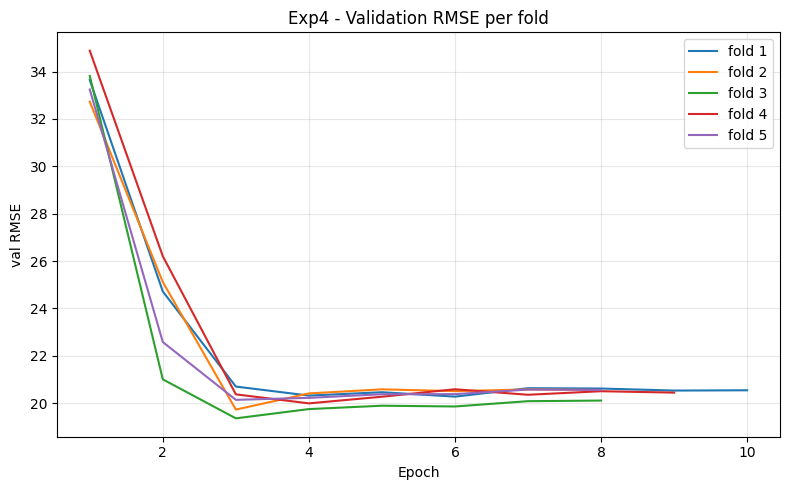

In [ ]:
from src.plot import plot_all_folds_history
plot_all_folds_history(out_dir, folds=[1,2,3,4,5], title_prefix="Exp4")

In [ ]:
#  Inspect worst error rows

errors_path = os.path.join(out_dir, "top50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()

,Id,fold,ytrue,oof_pred,abs_err
0,4ab407534f6153ba427f901eb2b45c5b,5,100,14.309258,85.690742
1,118ca1a5339f8d6f2794dfc7086ec46a,4,94,9.120928,84.879072
2,00768659c1c90409f81dcdecbd270513,1,100,18.864895,81.135105
3,bc39a9c4ae544bfc4118d59b9b089135,3,5,85.897041,80.897041
4,d26a260dddd3a5001f47bb9209e85b12,1,92,11.868005,80.131995


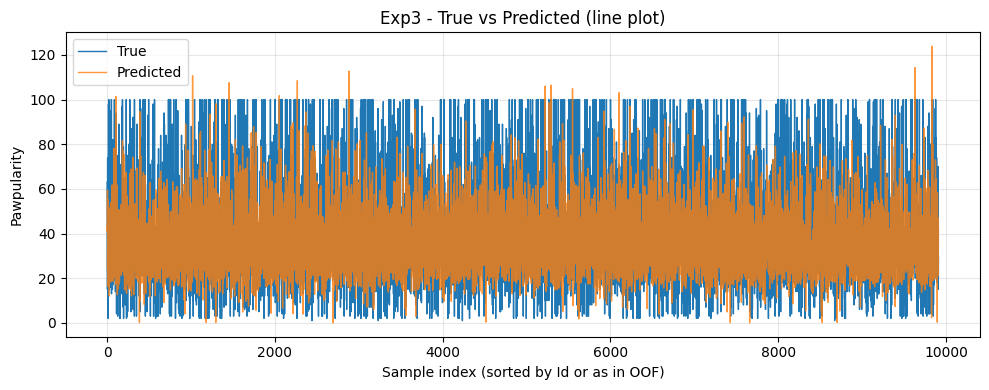

In [ ]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

# Load OOF detail and top-errors
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))
err_df = pd.read_csv(os.path.join(out_dir, "top50_errors.csv"))

# Plot
plot_oof_true_pred_lines(oof_df, title_prefix="Exp3")



